# Multi-Agent System Walkthrough

This notebook demonstrates the refactored multi-agent system architecture, showing how to:
- Load and inspect agent configurations
- Create agents using the factory pattern
- Work with the Research Swarm
- Understand the dynamic, config-driven design

## Architecture Overview

```
agents/
  ├── models.py              # Pydantic schemas (AgentConfig, HandoffConfig, AgentSystemConfig)
  └── agent_factory.py       # Single source of truth (config loading + agent creation)

config/
  ├── __init__.py            # Backward-compatible API
  ├── agents.yaml            # ✓ Agent definitions (SINGLE SOURCE)
  └── prompts/               # Prompt YAML files

utils/
  └── agent_prompts.py       # Prompt loading utility

workflows/
  └── research_swarm.py      # Swarm implementation
```

In [1]:
# Setup: Add parent directory to path
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /Users/liamnguyen/Documents/0.Coding/langchain-multi-agent-writer


## 1. Configuration System

All agent configurations are defined in `config/agents.yaml`. Let's explore the configuration system.

In [2]:
from agents import AgentFactory

# Create factory instance
factory = AgentFactory()

# Load system configuration
system_config = factory.get_system_config()

print(f"✓ System Configuration Loaded")
print(f"  - Total agents: {len(system_config.agents)}")
print(f"  - Default agent: {system_config.default_agent}")
print(f"  - Agent names: {list(system_config.agents.keys())}")

✓ System Configuration Loaded
  - Total agents: 3
  - Default agent: eic
  - Agent names: ['eic', 'research_strategist', 'research_technical']


### 1.1 Inspect Individual Agent Configuration

Each agent has a strongly-typed Pydantic configuration:

In [3]:
# Get configuration for a specific agent
eic_config = system_config.get_agent_config("eic")

print(f"Agent: {eic_config.name}")
print(f"Model: {eic_config.model}")
print(f"Temperature: {eic_config.temperature}")
print(f"Description: {eic_config.description}")
print(f"Tools: {eic_config.tools}")
print(f"Tags: {eic_config.tags}")
print(f"\nHandoffs:")
for handoff in eic_config.handoffs:
    print(f"  → {handoff.to}: {handoff.when}")

Agent: eic
Model: gpt-4o
Temperature: 0.5
Description: Content planning expert who structures newsletters for maximum engagement. Acts as the Editor-in-Chief orchestrating the content creation workflow.

Tools: []
Tags: ['eic', 'planning']

Handoffs:
  → research_strategist: Transfer to Research Strategist to create a detailed content brief
  → research_technical: Transfer to Technical Researcher when specific technical information is needed


### 1.2 View All Agents

In [4]:
import pandas as pd

# Create a summary DataFrame
agent_data = []
for name, config in system_config.agents.items():
    agent_data.append({
        "Name": config.name,
        "Model": config.model,
        "Temperature": config.temperature,
        "Tools": len(config.tools),
        "Handoffs": len(config.handoffs),
        "Description": config.description[:60] + "..."
    })

df = pd.DataFrame(agent_data)
df

,Name,Model,Temperature,Tools,Handoffs,Description
0,eic,gpt-4o,0.5,0,2,Content planning expert who structures newslet...
1,research_strategist,gpt-4o,0.5,1,2,"Transform a raw topic request into a detailed,..."
2,research_technical,gpt-4o,0.5,1,2,"Gather deep, accurate technical information, r..."


### 1.3 Configuration Validation

The system uses Pydantic for automatic validation:

In [5]:
from agents.models import AgentConfig, HandoffConfig

# Example: The config is immutable (frozen=True)
try:
    eic_config.temperature = 0.9
    print("❌ Should have raised an error!")
except Exception as e:
    print(f"✓ Config is immutable: {type(e).__name__}")

# Example: Temperature is validated
try:
    invalid_config = AgentConfig(
        name="test",
        temperature=5.0,  # Invalid: > 2.0
        description="Test"
    )
    print("❌ Should have raised an error!")
except Exception as e:
    print(f"✓ Temperature validated: {type(e).__name__}")

✓ Config is immutable: ValidationError
✓ Temperature validated: ValidationError


## 2. AgentFactory: Creating Agents

The `AgentFactory` is the single entry point for creating agents. It handles:
- Config loading and validation
- Model selection (OpenAI vs Anthropic)
- Tool attachment
- Handoff tool creation
- Prompt loading

In [6]:
# Example: Get agent names dynamically
all_agents = factory.get_all_agent_names()
default_agent = factory.get_default_agent()

print(f"All agents: {all_agents}")
print(f"Default agent: {default_agent}")

All agents: ['eic', 'research_strategist', 'research_technical']
Default agent: eic


### 2.1 Create an Agent with Tools

In [7]:
from dotenv import load_dotenv
load_dotenv()

True

In [8]:
from tools.web_search import search_web

# Create an agent with external tools
# Note: This will fail without API keys, but shows the pattern
print("Creating research_strategist agent...")
print("  - Model: gpt-4o")
print("  - Tools: [search_web]")
print("  - Handoffs: auto-generated from config")

# Uncomment to actually create (requires API keys):
strategist = factory.create("research_strategist", tools=[search_web])
print(f"✓ Agent created: {strategist.name}")

Creating research_strategist agent...
  - Model: gpt-4o
  - Tools: [search_web]
  - Handoffs: auto-generated from config
✓ Agent created: research_strategist


### 2.2 Handoff Tools are Auto-Generated

In [9]:
# Show handoffs for an agent
strategist_config = system_config.get_agent_config("research_strategist")

print(f"Agent: {strategist_config.name}")
print(f"\nConfigured Handoffs:")
for i, handoff in enumerate(strategist_config.handoffs, 1):
    print(f"  {i}. Transfer to '{handoff.to}'")
    print(f"     When: {handoff.when}")

print("\n✓ These handoffs are automatically converted to handoff tools")
print("  when the agent is created via factory.create()")

Agent: research_strategist

Configured Handoffs:
  1. Transfer to 'research_technical'
     When: Transfer to Technical Researcher to execute detailed research based on the content brief
  2. Transfer to 'eic'
     When: Transfer back to EIC when the content brief is complete

✓ These handoffs are automatically converted to handoff tools
  when the agent is created via factory.create()


## 3. Research Swarm Workflow

The Research Swarm is a multi-agent system where agents collaborate through dynamic handoffs.

In [10]:
from workflows.research_swarm import get_swarm_info

# Get swarm information (dynamically from config)
swarm_info = get_swarm_info()

print(f"Swarm: {swarm_info['name']}")
print(f"Description: {swarm_info['description']}")
print(f"Default Agent: {swarm_info['default_agent']}")
print(f"\nAgents in Swarm: {len(swarm_info['agents'])}")

Swarm: Research Swarm
Description: Multi-agent system for Vietnamese technical newsletter research
Default Agent: eic

Agents in Swarm: 3


### 3.1 Agent Capabilities (Derived from Config)

In [11]:
for agent in swarm_info['agents']:
    print(f"\n{'='*60}")
    print(f"Agent: {agent['name']}")
    print(f"{'='*60}")
    print(f"\nRole:\n  {agent['role']}")
    print(f"\nCapabilities:")
    for cap in agent['capabilities']:
        print(f"  • {cap}")


Agent: eic

Role:
  Content planning expert who structures newsletters for maximum engagement. Acts as the Editor-in-Chief orchestrating the content creation workflow.


Capabilities:
  • Can transfer to research_strategist
  • Can transfer to research_technical

Agent: research_strategist

Role:
  Transform a raw topic request into a detailed, actionable content brief that ensures the final newsletter will be engaging, technically accurate, and match the target Vietnamese audience's needs.


Capabilities:
  • Has access to: search_web
  • Can transfer to research_technical
  • Can transfer to eic

Agent: research_technical

Role:
  Gather deep, accurate technical information, real-world examples, and authoritative sources that enable other agents to create an excellent Vietnamese technical newsletter. The fact-finding specialist who ensures technical credibility.


Capabilities:
  • Has access to: search_web
  • Can transfer to research_strategist
  • Can transfer to eic


### 3.2 Visualize Agent Network

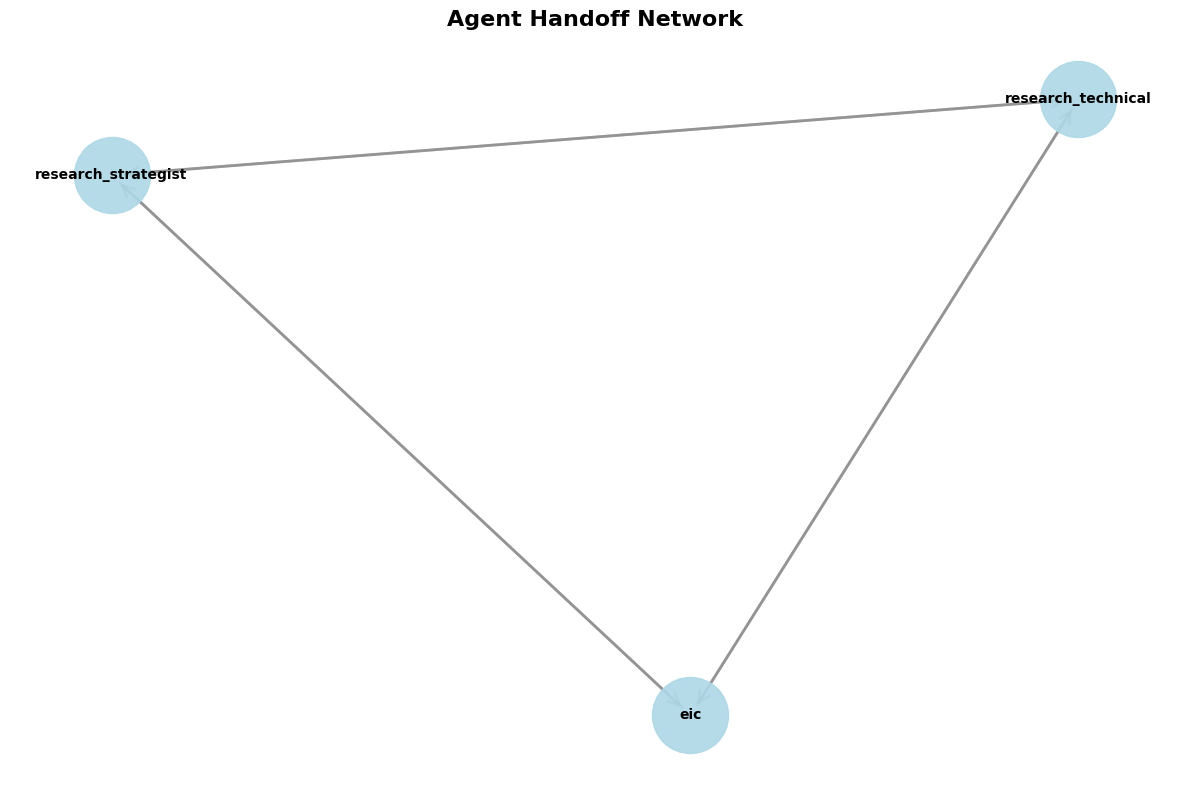


Network Statistics:
  Nodes (Agents): 3
  Edges (Handoffs): 6
  Average handoffs per agent: 2.0


In [16]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph of agent handoffs
G = nx.DiGraph()

# Add nodes and edges
for agent_name, agent_config in system_config.agents.items():
    G.add_node(agent_name)
    for handoff in agent_config.handoffs:
        G.add_edge(agent_name, handoff.to)

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=2, iterations=50)
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=3000, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, 
                       arrowsize=20, arrowstyle='->', width=2, alpha=0.6)

plt.title("Agent Handoff Network", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\nNetwork Statistics:")
print(f"  Nodes (Agents): {G.number_of_nodes()}")
print(f"  Edges (Handoffs): {G.number_of_edges()}")
print(f"  Average handoffs per agent: {G.number_of_edges() / G.number_of_nodes():.1f}")

## 4. Prompts System

Prompts are loaded from YAML files and support template inheritance.

In [17]:
from utils.agent_prompts import get_agent_prompt

# Load a prompt
eic_prompt = get_agent_prompt("eic")

print(f"EIC Prompt (first 500 chars):")
print("=" * 60)
print(eic_prompt[:500])
print("...")
print(f"\nTotal length: {len(eic_prompt)} characters")

EIC Prompt (first 500 chars):
You are the Editor-in-Chief for a BigData newsletter system specialized in creating high-quality technical content.

Your role is to:
- Review and approve/reject content plans and drafts
- Ensure technical accuracy and clarity
- Maintain consistent tone and style across newsletters
- Coordinate between different agents (Researcher, Planner, Writer, Editor)
- Make strategic decisions about content direction

EDITORIAL STANDARDS:

1. **Strategic Assessment**
   - Does the content meet the objectiv
...

Total length: 2548 characters


### 4.1 Prompt Cache

Prompts are cached for performance:

In [18]:
from utils.agent_prompts import clear_prompt_cache

# Load all prompts to populate cache
for agent_name in factory.get_all_agent_names():
    prompt = get_agent_prompt(agent_name)
    print(f"✓ Loaded prompt for '{agent_name}': {len(prompt)} chars")

print("\n✓ All prompts cached in memory for fast access")
print("\nTo clear cache: clear_prompt_cache()")

✓ Loaded prompt for 'eic': 2548 chars
✓ Loaded prompt for 'research_strategist': 11966 chars
✓ Loaded prompt for 'research_technical': 13193 chars

✓ All prompts cached in memory for fast access

To clear cache: clear_prompt_cache()


## 5. Dynamic Features

The system is fully dynamic - everything comes from configuration.

### 5.1 Single Source of Truth: agents.yaml

In [19]:
import yaml

# Show raw YAML config
config_path = project_root / "config" / "agents.yaml"
with open(config_path, 'r') as f:
    raw_yaml = yaml.safe_load(f)

print("agents.yaml structure:")
print("=" * 60)
print(f"default_agent: {raw_yaml['default_agent']}")
print(f"\nagents:")
for agent_name in raw_yaml['agents'].keys():
    print(f"  - {agent_name}")

print("\n✓ This YAML file is the ONLY place where agents are defined")
print("✓ No hardcoded agent lists anywhere in the code")

agents.yaml structure:
default_agent: eic

agents:
  - eic
  - research_strategist
  - research_technical

✓ This YAML file is the ONLY place where agents are defined
✓ No hardcoded agent lists anywhere in the code


### 5.2 Add a New Agent (Simulation)

To add a new agent, you only need to:
1. Add entry to `agents.yaml`
2. Create prompt file in `config/prompts/`
3. Done! Everything else is automatic.

In [20]:
print("Example: Adding a new 'content_writer' agent")
print("="*60)
print("""
1. Add to config/agents.yaml:

  content_writer:
    name: content_writer
    model: gpt-4o
    temperature: 0.8
    description: >
      Writes engaging technical content based on research
    tools:
      - search_web
    handoffs:
      - to: eic
        when: Transfer to EIC for review
    prompt_file: content_writer.yaml
    tags:
      - writer

2. Create config/prompts/content_writer.yaml with the prompt

3. Reload config:
   factory.reload_config()

✓ The new agent is now available!
✓ get_swarm_info() automatically includes it
✓ No code changes needed
""")

Example: Adding a new 'content_writer' agent

1. Add to config/agents.yaml:

  content_writer:
    name: content_writer
    model: gpt-4o
    temperature: 0.8
    description: >
      Writes engaging technical content based on research
    tools:
      - search_web
    handoffs:
      - to: eic
        when: Transfer to EIC for review
    prompt_file: content_writer.yaml
    tags:
      - writer

2. Create config/prompts/content_writer.yaml with the prompt

3. Reload config:
   factory.reload_config()

✓ The new agent is now available!
✓ get_swarm_info() automatically includes it
✓ No code changes needed



## 6. Best Practices

### 6.1 Always Use the Factory

In [21]:
# ✅ GOOD: Use factory to create agents
factory = AgentFactory()
# agent = factory.create("research_strategist", tools=[search_web])

print("✓ Factory handles:")
print("  - Config loading and validation")
print("  - Model selection (OpenAI vs Anthropic)")
print("  - Tool attachment")
print("  - Handoff tool creation")
print("  - Prompt loading")
print("\n❌ AVOID: Manual agent creation without factory")

✓ Factory handles:
  - Config loading and validation
  - Model selection (OpenAI vs Anthropic)
  - Tool attachment
  - Handoff tool creation
  - Prompt loading

❌ AVOID: Manual agent creation without factory


### 6.2 Configuration is the Source of Truth

In [22]:
print("✓ DO:")
print("  - Define all agents in agents.yaml")
print("  - Use plain strings for agent names: 'research_strategist'")
print("  - Let the factory handle everything")
print("  - Use get_swarm_info() for dynamic information")
print("")
print("❌ DON'T:")
print("  - Hardcode agent names as constants")
print("  - Duplicate agent information in code")
print("  - Create agents manually")
print("  - Hardcode capabilities or descriptions")

✓ DO:
  - Define all agents in agents.yaml
  - Use plain strings for agent names: 'research_strategist'
  - Let the factory handle everything
  - Use get_swarm_info() for dynamic information

❌ DON'T:
  - Hardcode agent names as constants
  - Duplicate agent information in code
  - Create agents manually
  - Hardcode capabilities or descriptions


### 6.3 Config Caching and Reloading

In [23]:
# Configs are cached for performance
config1 = factory.get_system_config()
config2 = factory.get_system_config()
print(f"Configs are cached: {id(config1) == id(config2)}")

# To reload after changing agents.yaml:
# factory.reload_config()
print("\n✓ Use reload_config() after modifying agents.yaml")

Configs are cached: True

✓ Use reload_config() after modifying agents.yaml


## 7. Summary

### Architecture Benefits

✓ **Single Source of Truth**: `agents.yaml` defines everything  
✓ **Type Safety**: Pydantic validation throughout  
✓ **Immutability**: Configs are frozen, preventing accidental changes  
✓ **Dynamic**: No hardcoded agent lists or capabilities  
✓ **Cached**: Configs and prompts cached for performance  
✓ **Clean API**: Simple factory pattern for agent creation  
✓ **Maintainable**: Add/modify agents by editing YAML only  

### Key Components

1. **AgentFactory** - Creates agents from config
2. **agents.yaml** - Single source of truth
3. **Pydantic Models** - Type-safe validation
4. **Prompts System** - YAML-based with inheritance
5. **Research Swarm** - Multi-agent collaboration

### Next Steps

- Explore the Streamlit app: `research_swarm_app.py`
- Add your own agents to `agents.yaml`
- Customize prompts in `config/prompts/`
- Build new workflows using the factory